<a href="https://colab.research.google.com/github/ViniciusPolachini/Atividades_visao_computacional/blob/main/Atividade_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics --upgrade
!pip install opencv-python matplotlib
!pip install -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import torch
from PIL import Image
import gc
from torch.nn.functional import cosine_similarity
import matplotlib.pyplot as plt
from ultralytics import YOLO
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, BlipProcessor, BitsAndBytesConfig, AutoConfig,BlipForConditionalGeneration, CLIPProcessor, CLIPModel, AutoModelForCausalLM, AutoTokenizer, pipeline

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
yolo_model = YOLO('yolov8n.pt').to(device)

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model_id = "Qwen/Qwen3-VL-8B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer_llm = AutoTokenizer.from_pretrained(model_id)
model_llm = Qwen3VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="cuda",
    trust_remote_code=True
)
model_llm.eval()

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Qwen3VLForConditionalGeneration(
  (model): Qwen3VLModel(
    (visual): Qwen3VLVisionModel(
      (patch_embed): Qwen3VLVisionPatchEmbed(
        (proj): Conv3d(3, 1152, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
      (pos_embed): Embedding(2304, 1152)
      (rotary_pos_emb): Qwen3VLVisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-26): 27 x Qwen3VLVisionBlock(
          (norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
          (attn): Qwen3VLVisionAttention(
            (qkv): Linear4bit(in_features=1152, out_features=3456, bias=True)
            (proj): Linear4bit(in_features=1152, out_features=1152, bias=True)
          )
          (mlp): Qwen3VLVisionMLP(
            (linear_fc1): Linear4bit(in_features=1152, out_features=4304, bias=True)
            (linear_fc2): Linear4bit(in_features=4304, out_features=1152, bias=True)
            (act_fn): GELUTanh()
          )
   

In [ ]:
def yolo_labels(image):
  yolo_results = yolo_model(image, device=device, verbose=False)
  return [yolo_model.names[int(c)] for c in yolo_results[0].boxes.cls], yolo_results

In [ ]:
def blip_descrpitions(image, labels):
  outputs = []
  cache = {}
  for label in labels:
    if label not in cache:
      prompt_guiado = f"a photo of {label} where the {label} are"
      inputs_blip = blip_processor(image, prompt_guiado, return_tensors="pt").to(device)
      with torch.no_grad():
          out_blip = blip_model.generate(**inputs_blip, max_new_tokens=50)
      blip_output = blip_processor.decode(out_blip[0], skip_special_tokens=True)
      outputs.append(blip_output)
      cache[label] = ""
  return outputs


In [ ]:
conceitos_risco = [
        "a dangerous traffic situation with pedestrians and cars",
        "a dangerous traffic situation with animals and cars",
        "a dangerous traffic situation with two or more vehicles",
        "an animal in a safe place",
        "a person safely walking on the sidewalk",
        "a normal city street scene",
        "cars parked on the street",
        "cars driving saffely"
  ]

In [ ]:
def clip_process(image):
  inputs_clip = clip_processor(
      text= conceitos_risco,
      images=image,
      return_tensors="pt",
      padding=True
  ).to(device)

  with torch.no_grad():
      outputs_clip = clip_model(**inputs_clip)
      logits_per_image = outputs_clip.logits_per_image
      probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

  scores_mapeados = {
      conceito: f"{float(score):.2%}"
      for conceito, score in zip(conceitos_risco, probs)
  }

  return scores_mapeados

In [ ]:
def fusao(labels, details, probs, image_path):
    print(probs)
    print(labels)
    print(details)
    prompt = f"""
    You are a driver with good road safety knowledge.
    You will receive a photo that is your perspective as a driver.
    Combine the following computer vision information into a single diagnostic sentence.
    Structured detections (YOLO): {labels}
    Detailed descriptions (BLIP): {details}
    Probability analysis (CLIP): {probs}
    Observation: The clip present dangeours scenarios probability but also safe scenarios
    Expected output: A short and direct sentence interpreting whether there is a risk or not.
    """

    messages = [
        {"role": "system", "content": "You are a driver who needs to say if an trafic situation is danger."},
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image_path},
                {"type": "text",  "text": prompt}
            ]
        }
    ]

    text = tokenizer_llm.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer_llm([text], return_tensors="pt").to("cuda")

    generated_ids = model_llm.generate(model_inputs.input_ids, max_new_tokens=150, do_sample=False)
    response = tokenizer_llm.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response.split("assistant\n")[-1].strip()

In [ ]:
def processar_projeto_visao(img_path):
    gc.collect()
    torch.cuda.empty_cache()

    raw_image = Image.open(img_path).convert('RGB')
    labels, yolo_results = yolo_labels(raw_image)
    yolo_output = ", ".join(list(set(labels))) if labels else "no relevant objects"

    blip_outputs = blip_descrpitions(raw_image, labels)

    probs = clip_process(raw_image)

    interpretacao_final = fusao(labels, blip_outputs, probs,img_path)

    exibir_resultados(yolo_results[0], yolo_output, blip_outputs, interpretacao_final, probs)

def exibir_resultados(y_res, y_out, b_out, f_out, probs):
    res_plotted = y_res.plot()
    plt.figure(figsize=(10, 6))
    plt.imshow(res_plotted[:, :, ::-1])
    plt.axis('off')
    plt.show()

    print(f"\n{'='*30}")
    print(f"YOLO  → \"{y_out}\"\n\n")
    print(f"BLIP  → \"{b_out}\"\n\n")
    print(f"CLIP -> \"{probs}\"\n\n")
    print(f"FUSÃO → \"{f_out}\"\n\n")
    print(f"{'='*30}\n")

{'a dangerous traffic situation with pedestrians and cars': '70.21%', 'a dangerous traffic situation with animals and cars': '0.50%', 'a dangerous traffic situation with two or more vehicles': '1.60%', 'an animal in a safe place': '0.00%', 'a person safely walking on the sidewalk': '11.98%', 'a normal city street scene': '15.49%', 'cars parked on the street': '0.11%', 'cars driving saffely': '0.11%'}
['person', 'person', 'car', 'car', 'handbag', 'person', 'car', 'backpack', 'handbag']
['a photo of person where the person are walking across the street', 'a photo of car where the car are driving on the street', "a photo of handbag where the handbag are used to carry the city ' s most traffic signals", 'a photo of backpack where the backpack are on the street']


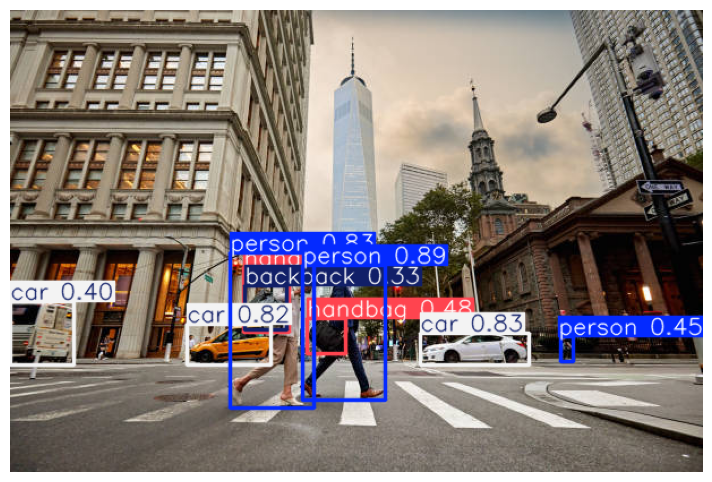


YOLO  → "car, backpack, handbag, person"


BLIP  → "['a photo of person where the person are walking across the street', 'a photo of car where the car are driving on the street', "a photo of handbag where the handbag are used to carry the city ' s most traffic signals", 'a photo of backpack where the backpack are on the street']"


CLIP -> "{'a dangerous traffic situation with pedestrians and cars': '70.21%', 'a dangerous traffic situation with animals and cars': '0.50%', 'a dangerous traffic situation with two or more vehicles': '1.60%', 'an animal in a safe place': '0.00%', 'a person safely walking on the sidewalk': '11.98%', 'a normal city street scene': '15.49%', 'cars parked on the street': '0.11%', 'cars driving saffely': '0.11%'}"


FUSÃO → "Dangerous traffic situation: pedestrians and cars are mixed on the street."



{'a dangerous traffic situation with pedestrians and cars': '35.02%', 'a dangerous traffic situation with animals and cars': '53.55%', 'a dangerous traffic situa

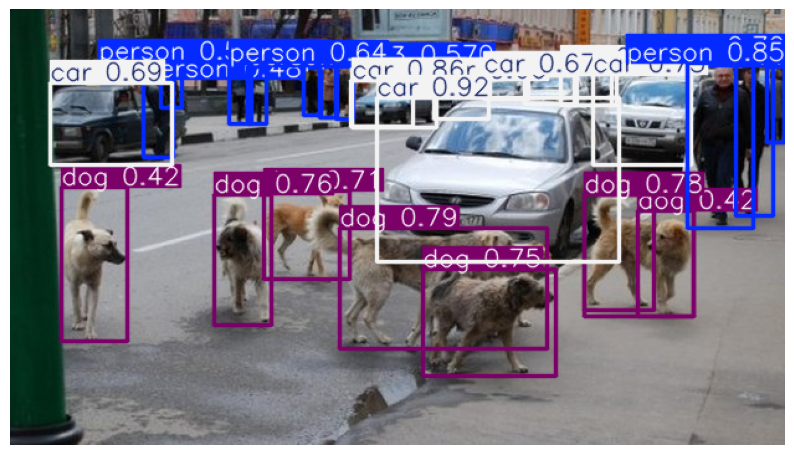


YOLO  → "car, dog, person"


BLIP  → "['a photo of car where the car are parked', 'a photo of person where the person are walking their dogs', 'a photo of dog where the dog are walking']"


CLIP -> "{'a dangerous traffic situation with pedestrians and cars': '35.02%', 'a dangerous traffic situation with animals and cars': '53.55%', 'a dangerous traffic situation with two or more vehicles': '5.57%', 'an animal in a safe place': '0.05%', 'a person safely walking on the sidewalk': '0.18%', 'a normal city street scene': '5.48%', 'cars parked on the street': '0.08%', 'cars driving saffely': '0.08%'}"


FUSÃO → "This is a dangerous traffic situation due to multiple cars, pedestrians, and dogs in close proximity."



{'a dangerous traffic situation with pedestrians and cars': '24.46%', 'a dangerous traffic situation with animals and cars': '0.75%', 'a dangerous traffic situation with two or more vehicles': '1.79%', 'an animal in a safe place': '0.02%', 'a person safely walking on the sidewal

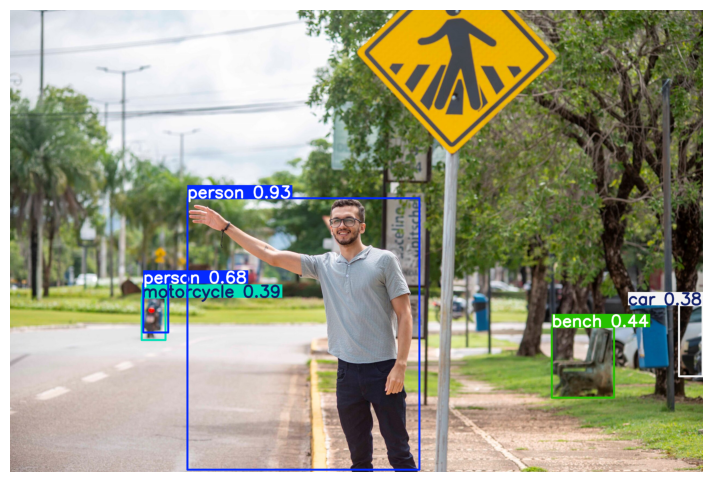


YOLO  → "car, bench, motorcycle, person"


BLIP  → "['a photo of person where the person are crossing the street', 'a photo of bench where the bench are on the street', 'a photo of motorcycle where the motorcycle are not allowed', 'a photo of car where the car are parked']"


CLIP -> "{'a dangerous traffic situation with pedestrians and cars': '24.46%', 'a dangerous traffic situation with animals and cars': '0.75%', 'a dangerous traffic situation with two or more vehicles': '1.79%', 'an animal in a safe place': '0.02%', 'a person safely walking on the sidewalk': '71.83%', 'a normal city street scene': '0.98%', 'cars parked on the street': '0.04%', 'cars driving saffely': '0.12%'}"


FUSÃO → "There is a potential danger: pedestrians are crossing the street near parked cars and a motorcycle in an unauthorized area."



{'a dangerous traffic situation with pedestrians and cars': '16.81%', 'a dangerous traffic situation with animals and cars': '8.33%', 'a dangerous traffic situation with 

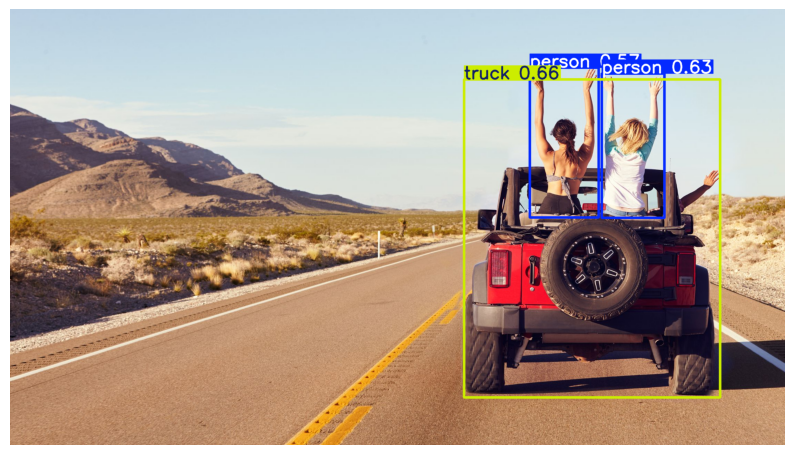


YOLO  → "truck, person"


BLIP  → "['a photo of truck where the truck are driving', 'a photo of person where the person are on a jeep']"


CLIP -> "{'a dangerous traffic situation with pedestrians and cars': '16.81%', 'a dangerous traffic situation with animals and cars': '8.33%', 'a dangerous traffic situation with two or more vehicles': '58.01%', 'an animal in a safe place': '0.10%', 'a person safely walking on the sidewalk': '0.29%', 'a normal city street scene': '1.15%', 'cars parked on the street': '0.86%', 'cars driving saffely': '14.45%'}"


FUSÃO → "Dangerous traffic situation: pedestrians and vehicles are in close proximity."





In [ ]:
processar_projeto_visao("/imagem_teste.jpg")
processar_projeto_visao("/cachorros_na_rua.jpg")
processar_projeto_visao("/pedestre_fora_da_rua.jpg")
processar_projeto_visao("/via_segura.jpg")